# Sweet-Parker Reconnection Model — Implementation / 구현

**Paper**: Parker, E. N. (1957). "Sweet's Mechanism for Merging Magnetic Fields in Conducting Fluids." *J. Geophys. Res.*, 62(4), 509–520.

This notebook implements the key results of the Sweet-Parker magnetic reconnection model:
이 노트북은 Sweet-Parker 자기 재결합 모델의 핵심 결과를 구현합니다:

1. **Sweet-Parker scaling relations** — 병합 속도, 전이층 두께, 재결합 시간 계산 / Merging velocity, layer thickness, reconnection time
2. **Fluid expulsion dynamics** — Section II의 유체 방출 과정 시뮬레이션 / Simulation of fluid expulsion (Section II)
3. **Master ODE & Figure 3 reproduction** — Eq. 26의 수치 해와 Figure 3 재현 / Numerical solution of Eq. 26 and Figure 3 reproduction
4. **Reconnection rate comparison** — Sweet-Parker vs Petschek vs 순수 확산 비교 / Comparison across models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part 1: Sweet-Parker Scaling Relations / Sweet-Parker 스케일링 관계

Parker의 핵심 결과는 병합 속도가 다음과 같이 주어진다는 것입니다 (CGS 단위):
Parker's key result is that the merging velocity is given by (CGS units):

$$v_m = 0.263\, c \left(\frac{C}{\sigma L}\right)^{1/2}$$

SI 단위로 변환하면 / In SI units:

$$v_m = \frac{v_A}{\sqrt{R_m}}, \quad R_m = \frac{v_A L}{\eta}, \quad v_A = \frac{B}{\sqrt{\mu_0 \rho}}, \quad \eta = \frac{1}{\mu_0 \sigma}$$

여기서는 SI 단위를 사용하여 태양 코로나, 태양풍, 실험실 플라즈마의 재결합 매개변수를 계산합니다.
We use SI units to calculate reconnection parameters for the solar corona, solar wind, and laboratory plasmas.

In [2]:
# Physical constants (SI)
mu_0 = 4 * np.pi * 1e-7       # Permeability of free space [H/m]
c_light = 3e8                  # Speed of light [m/s]
k_B = 1.38e-23                 # Boltzmann constant [J/K]
m_e = 9.11e-31                 # Electron mass [kg]
e_charge = 1.6e-19             # Elementary charge [C]
m_p = 1.67e-27                 # Proton mass [kg]


def sweet_parker_params(B, n, L, T, label=""):
    """Compute Sweet-Parker reconnection parameters in SI units.

    Args:
        B: Magnetic field strength [T]
        n: Number density [m^-3]
        L: Global length scale [m]
        T: Temperature [K]
        label: Label for the environment

    Returns:
        Dictionary of Sweet-Parker parameters.
    """
    rho = n * m_p                                    # Mass density [kg/m^3]
    v_A = B / np.sqrt(mu_0 * rho)                    # Alfvén speed [m/s]

    # Spitzer resistivity (fully ionized hydrogen plasma)
    ln_Lambda = 23.0 - np.log(np.sqrt(n * 1e-6) / T**(3/2))  # Coulomb logarithm
    eta = 5.2e-5 * ln_Lambda / T**1.5                # Magnetic diffusivity [m^2/s]
    sigma = 1.0 / (mu_0 * eta)                       # Conductivity [S/m]

    R_m = v_A * L / eta                              # Magnetic Reynolds number
    v_in = v_A / np.sqrt(R_m)                        # Inflow (merging) velocity [m/s]
    delta = L / np.sqrt(R_m)                         # Layer thickness [m]
    tau_SP = L / v_in                                # Reconnection time [s]
    tau_diff = L**2 / eta                            # Pure diffusion time [s]
    tau_A = L / v_A                                  # Alfvén crossing time [s]

    result = {
        'label': label,
        'B [T]': B,
        'n [m^-3]': n,
        'L [m]': L,
        'T [K]': T,
        'rho [kg/m^3]': rho,
        'v_A [m/s]': v_A,
        'eta [m^2/s]': eta,
        'sigma [S/m]': sigma,
        'R_m': R_m,
        'v_in [m/s]': v_in,
        'delta [m]': delta,
        'delta/L': delta / L,
        'tau_SP [s]': tau_SP,
        'tau_diff [s]': tau_diff,
        'tau_A [s]': tau_A,
        'tau_SP/tau_A': tau_SP / tau_A,
        'speedup': tau_diff / tau_SP,
    }
    return result


def print_params(p):
    """Print Sweet-Parker parameters in a readable format."""
    print(f"=== {p['label']} ===")
    print(f"  B = {p['B [T]']:.2e} T,  n = {p['n [m^-3]']:.2e} m^-3")
    print(f"  L = {p['L [m]']:.2e} m,  T = {p['T [K]']:.2e} K")
    print(f"  v_A = {p['v_A [m/s]']:.2e} m/s = {p['v_A [m/s]']/1e3:.1f} km/s")
    print(f"  eta = {p['eta [m^2/s]']:.2e} m^2/s")
    print(f"  R_m = {p['R_m']:.2e}")
    print(f"  --- Sweet-Parker Results ---")
    print(f"  v_in = {p['v_in [m/s]']:.2e} m/s = {p['v_in [m/s]']*1e3:.2f} mm/s")
    print(f"  delta = {p['delta [m]']:.2e} m = {p['delta [m]']:.1f} m")
    print(f"  delta/L = {p['delta/L']:.2e}")
    print(f"  tau_SP = {p['tau_SP [s]']:.2e} s = {p['tau_SP [s]']/3600:.1f} hr = {p['tau_SP [s]']/(3600*24):.1f} days")
    print(f"  tau_diff = {p['tau_diff [s]']:.2e} s = {p['tau_diff [s]']/(3600*24*365):.1f} yr")
    print(f"  tau_A = {p['tau_A [s]']:.2e} s = {p['tau_A [s]']:.1f} s")
    print(f"  tau_SP / tau_A = sqrt(R_m) = {p['tau_SP/tau_A']:.2e}")
    print(f"  Speedup over diffusion: {p['speedup']:.2e}x")
    print()

In [3]:
# ── Parker's original numerical example (p. 511-512) ──
# B = 1000 G = 0.1 T, L ≈ 10^9 cm = 10^7 m
# sigma ≈ 1.8 × 10^13 esu, rho = 10^-8 g/cm^3 = 10^-5 kg/m^3
# → C_0 ≈ 100 km/s, u ≈ 7 m/s, l/L ≈ 0.7 × 10^-4

# Solar corona
corona = sweet_parker_params(
    B=0.01,       # 100 G = 0.01 T (active region corona)
    n=1e15,       # 10^15 m^-3 (coronal density)
    L=1e7,        # 10^7 m = 10^4 km (active region scale)
    T=1e6,        # 10^6 K (coronal temperature)
    label="Solar Corona (Active Region)"
)
print_params(corona)

# Parker's sunspot example (as in the paper)
sunspot = sweet_parker_params(
    B=0.1,        # 1000 G = 0.1 T
    n=6e18,       # rho = 10^-8 g/cm^3 → n ≈ 6×10^18 m^-3
    L=1e7,        # L ≈ 10^9 cm = 10^7 m
    T=1e4,        # Photospheric temperature
    label="Parker's Sunspot Example (p. 511)"
)
print_params(sunspot)

# Solar wind at 1 AU
solar_wind = sweet_parker_params(
    B=5e-9,       # 5 nT
    n=5e6,        # 5 cm^-3
    L=1e9,        # 10^6 km
    T=1e5,        # 10^5 K
    label="Solar Wind at 1 AU"
)
print_params(solar_wind)

=== Solar Corona (Active Region) ===
  B = 1.00e-02 T,  n = 1.00e+15 m^-3
  L = 1.00e+07 m,  T = 1.00e+06 K
  v_A = 6.90e+06 m/s = 6903.0 km/s
  eta = 1.73e-12 m^2/s
  R_m = 3.98e+25
  --- Sweet-Parker Results ---
  v_in = 1.09e-06 m/s = 0.00 mm/s
  delta = 1.59e-06 m = 0.0 m
  delta/L = 1.59e-13
  tau_SP = 9.14e+12 s = 2538363191.4 hr = 105765133.0 days
  tau_diff = 5.76e+25 s = 1827859246235542016.0 yr
  tau_A = 1.45e+00 s = 1.4 s
  tau_SP / tau_A = sqrt(R_m) = 6.31e+12
  Speedup over diffusion: 6.31e+12x

=== Parker's Sunspot Example (p. 511) ===
  B = 1.00e-01 T,  n = 6.00e+18 m^-3
  L = 1.00e+07 m,  T = 1.00e+04 K
  v_A = 8.91e+05 m/s = 891.2 km/s
  eta = 1.15e-09 m^2/s
  R_m = 7.75e+21
  --- Sweet-Parker Results ---
  v_in = 1.01e-05 m/s = 0.01 mm/s
  delta = 1.14e-04 m = 0.0 m
  delta/L = 1.14e-11
  tau_SP = 9.88e+11 s = 274459714.0 hr = 11435821.4 days
  tau_diff = 8.70e+22 s = 2758778384636267.0 yr
  tau_A = 1.12e+01 s = 11.2 s
  tau_SP / tau_A = sqrt(R_m) = 8.81e+10
  Speedup

### Reconnection rate vs $R_m$ / 재결합 속도 vs $R_m$

Sweet-Parker 재결합 속도 $M_A = v_{in}/v_A = R_m^{-1/2}$를 $R_m$의 함수로 그립니다. 태양 코로나에서 $R_m \sim 10^{12}$이므로 $M_A \sim 10^{-6}$ — 관측된 플레어의 재결합 속도 $M_A \sim 0.01$–$0.1$에 비해 $10^4$–$10^5$배 느립니다.

We plot the Sweet-Parker reconnection rate $M_A = v_{in}/v_A = R_m^{-1/2}$ as a function of $R_m$. In the solar corona with $R_m \sim 10^{12}$, $M_A \sim 10^{-6}$ — $10^4$–$10^5$ times slower than observed flare reconnection rates of $M_A \sim 0.01$–$0.1$.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/2627222577.py:39: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/2627222577.py:39: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/2627222577.py:39: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/2627222577.py:39: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/2627222577.py:39: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyke

Font 'default' does not have a glyph for '\uce21' [U+ce21], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub41c' [U+b41c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ud50c' [U+d50c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub808' [U+b808], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\ud50c' [U+d50c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub808' [U+b808], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc5b4' [U+c5b4], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc18d' [U+c18d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


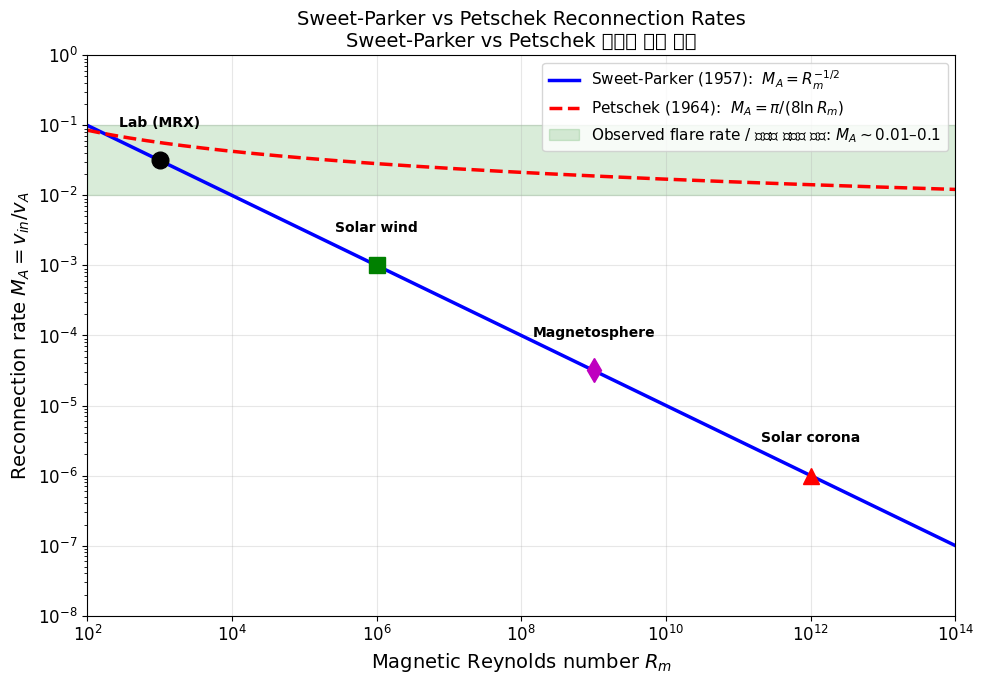

Sweet-Parker 재결합이 얼마나 느린지 한눈에 보입니다!
The slow reconnection problem is immediately visible!


In [4]:
R_m = np.logspace(2, 14, 500)

# Sweet-Parker: M_A = R_m^(-1/2)
M_SP = R_m**(-0.5)

# Petschek (1964): M_A ~ pi / (8 ln R_m)
M_Petschek = np.pi / (8 * np.log(R_m))

fig, ax = plt.subplots(figsize=(10, 7))

ax.loglog(R_m, M_SP, 'b-', lw=2.5, label='Sweet-Parker (1957):  $M_A = R_m^{-1/2}$')
ax.loglog(R_m, M_Petschek, 'r--', lw=2.5, label='Petschek (1964):  $M_A = \\pi / (8 \\ln R_m)$')

# Observed flare reconnection rate band
ax.axhspan(0.01, 0.1, alpha=0.15, color='green',
           label='Observed flare rate / 관측된 플레어 속도: $M_A \\sim 0.01$–$0.1$')

# Mark key environments
envs = {
    'Lab (MRX)': (1e3, 'ko'),
    'Solar wind': (1e6, 'gs'),
    'Magnetosphere': (1e9, 'md'),
    'Solar corona': (1e12, 'r^'),
}
for name, (Rm_val, marker) in envs.items():
    M_val = Rm_val**(-0.5)
    ax.plot(Rm_val, M_val, marker, ms=12, zorder=5)
    offset_y = 3.0
    ax.annotate(name, (Rm_val, M_val * offset_y), fontsize=10,
                ha='center', fontweight='bold')

ax.set_xlabel('Magnetic Reynolds number $R_m$', fontsize=14)
ax.set_ylabel('Reconnection rate $M_A = v_{in}/v_A$', fontsize=14)
ax.set_title('Sweet-Parker vs Petschek Reconnection Rates\n'
             'Sweet-Parker vs Petschek 재결합 속도 비교', fontsize=14)
ax.set_xlim(1e2, 1e14)
ax.set_ylim(1e-8, 1)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.savefig('fig1_reconnection_rate_vs_Rm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sweet-Parker 재결합이 얼마나 느린지 한눈에 보입니다!")
print("The slow reconnection problem is immediately visible!")

## Part 2: Fluid Expulsion Dynamics / 유체 방출 역학 (Section II)

Parker는 Section II에서 두 반평행 자기장 사이에 갇힌 유체가 자기 압력에 의해 짜내지는 과정을 분석합니다.
유체 원소의 궤적 $Y(t)$가 Eq. 5로 주어지며, 유출 속도 $v_y$는 Eq. 8, 전이층 두께 $l(y,t)$는 Eq. 10으로 주어집니다.

Parker analyzes in Section II how fluid trapped between two antiparallel fields is squeezed out by magnetic pressure.
The fluid element trajectory $Y(t)$ is given by Eq. 5, outflow velocity $v_y$ by Eq. 8, and layer thickness $l(y,t)$ by Eq. 10.

$$v_y = 2C_0(y/a)(C_0 t/a) \exp(-2y^2/b^2)$$
$$l(y,t) = l(y,0)\left\{1 - (C_0 t/a)^2(1 - 4y^2/b^2)\exp(-2y^2/b^2)\right\}$$

Font 'default' does not have a glyph for '\uc720' [U+c720], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ucd9c' [U+cd9c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc18d' [U+c18d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/3537363417.py:96: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/3537363417.py:96: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/3537363417.py:96: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/3537363417.py:96: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/3537363417.py:96: UserWarning: Glyph 44760 (\N{HANGUL SYLLABLE GGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipyker

...

Font 'default' does not have a glyph for '\ucd9c' [U+cd9c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\uc18d' [U+c18d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\ub3c4' [U+b3c4], substituting with a dummy symbol.


/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Sof

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


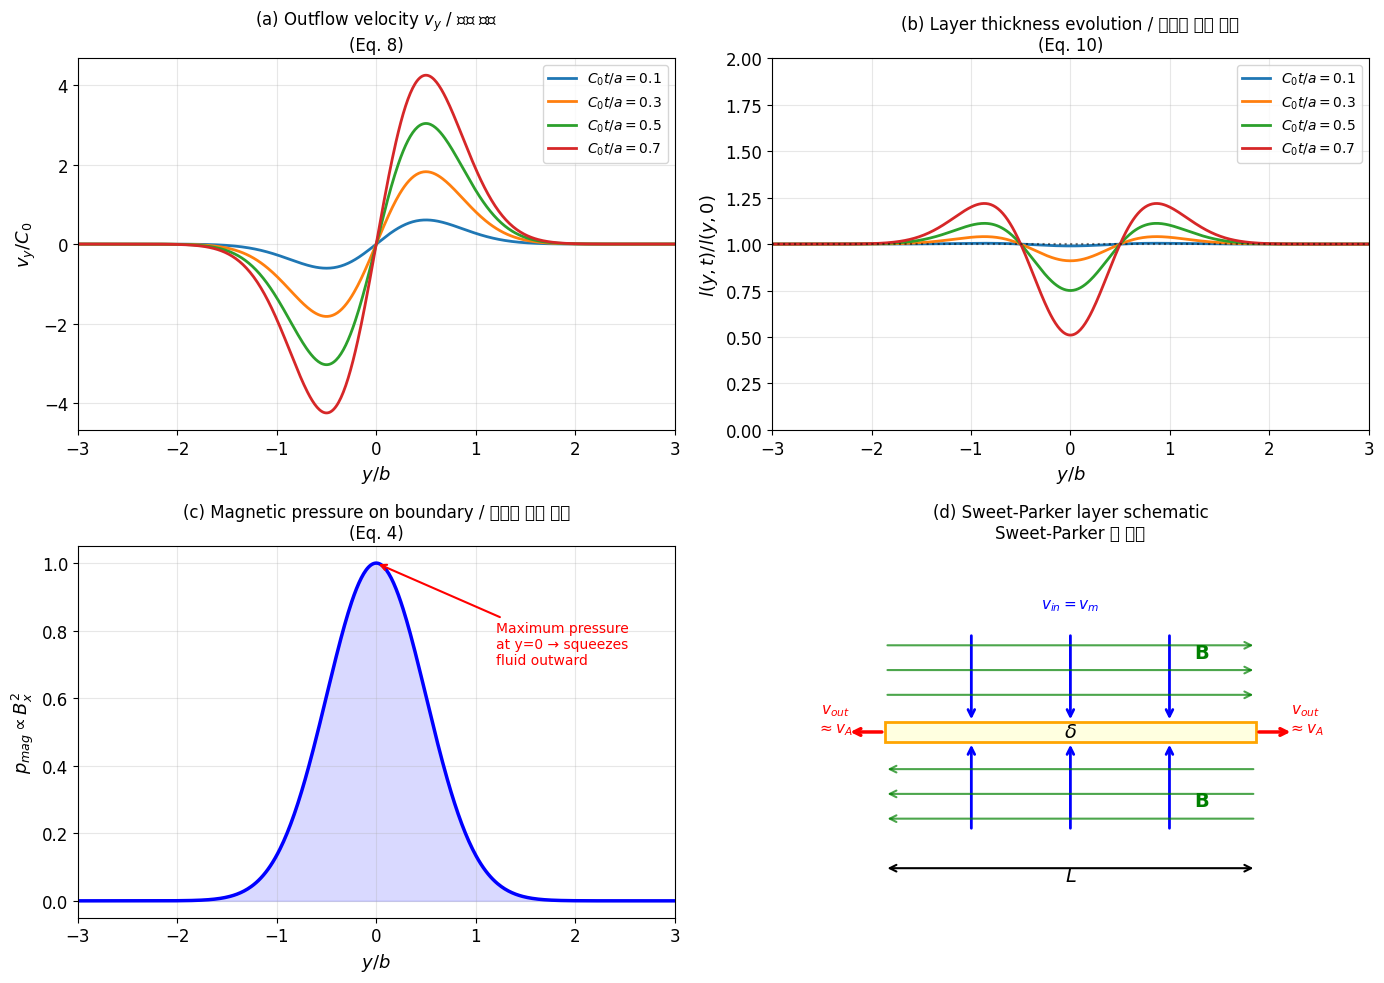

In [5]:
# Parameters for the idealized model
a = 1.0    # Half-separation of conducting sheets (normalized)
b = 10.0   # Gaussian field scale (b >> a)
C0 = 1.0   # Hydromagnetic velocity (normalized)

y = np.linspace(-3 * b, 3 * b, 500)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (a) Outflow velocity v_y at different times ──
ax = axes[0, 0]
for tau_label, tau in [('0.1', 0.1), ('0.3', 0.3), ('0.5', 0.5), ('0.7', 0.7)]:
    # Eq. 8: v_y = 2*C0*(y/a)*(C0*t/a) * exp(-2y^2/b^2), leading order
    v_y = 2 * C0 * (y / a) * (C0 * float(tau) / a) * np.exp(-2 * y**2 / b**2)
    ax.plot(y / b, v_y / C0, lw=2, label=f'$C_0 t/a = {tau_label}$')
ax.set_xlabel('$y / b$', fontsize=13)
ax.set_ylabel('$v_y / C_0$', fontsize=13)
ax.set_title('(a) Outflow velocity $v_y$ / 유출 속도\n(Eq. 8)', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(-3, 3)

# ── (b) Layer thickness l(y,t) / l(y,0) ──
ax = axes[0, 1]
for tau_label, tau in [('0.1', 0.1), ('0.3', 0.3), ('0.5', 0.5), ('0.7', 0.7)]:
    # Eq. 10: l(y,t)/l(y,0) = 1 - (C0*t/a)^2 * (1 - 4y^2/b^2) * exp(-2y^2/b^2)
    ratio = 1 - (C0 * float(tau) / a)**2 * (1 - 4 * y**2 / b**2) * np.exp(-2 * y**2 / b**2)
    ax.plot(y / b, ratio, lw=2, label=f'$C_0 t/a = {tau_label}$')
ax.set_xlabel('$y / b$', fontsize=13)
ax.set_ylabel('$l(y,t) / l(y,0)$', fontsize=13)
ax.set_title('(b) Layer thickness evolution / 전이층 두께 진화\n(Eq. 10)', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(1.0, color='k', ls=':', alpha=0.5)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 2)

# ── (c) Magnetic pressure profile at the boundary ──
ax = axes[1, 0]
# From Eq. 4: B_x(±ε, y) ~ (B0*b / 2a^2) exp(-y^2/b^2)
B_x = np.exp(-y**2 / b**2)
p_mag = B_x**2  # ∝ B^2/(8π)
ax.plot(y / b, p_mag, 'b-', lw=2.5)
ax.fill_between(y / b, 0, p_mag, alpha=0.15, color='blue')
ax.set_xlabel('$y / b$', fontsize=13)
ax.set_ylabel('$p_{mag} \\propto B_x^2$', fontsize=13)
ax.set_title('(c) Magnetic pressure on boundary / 경계면 자기 압력\n(Eq. 4)', fontsize=12)
ax.set_xlim(-3, 3)
ax.annotate('Maximum pressure\nat y=0 → squeezes\nfluid outward',
            xy=(0, 1), xytext=(1.2, 0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, color='red')

# ── (d) Schematic: Sweet-Parker layer geometry ──
ax = axes[1, 1]
ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# Current sheet
rect = plt.Rectangle((-1.5, -0.08), 3.0, 0.16, fc='lightyellow', ec='orange', lw=2)
ax.add_patch(rect)

# Inflow arrows
for x_pos in [-0.8, 0, 0.8]:
    ax.annotate('', xy=(x_pos, 0.08), xytext=(x_pos, 0.8),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
    ax.annotate('', xy=(x_pos, -0.08), xytext=(x_pos, -0.8),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))

# Outflow arrows
ax.annotate('', xy=(1.8, 0), xytext=(1.5, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.annotate('', xy=(-1.8, 0), xytext=(-1.5, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))

# Field lines (horizontal, antiparallel)
for y_pos in [0.3, 0.5, 0.7]:
    ax.annotate('', xy=(1.5, y_pos), xytext=(-1.5, y_pos),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5, alpha=0.7))
    ax.annotate('', xy=(-1.5, -y_pos), xytext=(1.5, -y_pos),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5, alpha=0.7))

# Labels
ax.text(0, 0, '$\\delta$', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0, -1.2, '$L$', ha='center', fontsize=14, fontweight='bold')
ax.annotate('', xy=(1.5, -1.1), xytext=(-1.5, -1.1),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(1.9, 0, '$v_{out}$\n$\\approx v_A$', ha='center', fontsize=11, color='red')
ax.text(-1.9, 0, '$v_{out}$\n$\\approx v_A$', ha='center', fontsize=11, color='red')
ax.text(0, 1.0, '$v_{in} = v_m$', ha='center', fontsize=11, color='blue')
ax.text(1.0, 0.6, '$\\mathbf{B}$', fontsize=14, color='green', fontweight='bold')
ax.text(1.0, -0.6, '$\\mathbf{B}$', fontsize=14, color='green', fontweight='bold')

ax.set_title('(d) Sweet-Parker layer schematic\nSweet-Parker 층 도식', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig('fig2_fluid_expulsion.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3: Master ODE & Figure 3 Reproduction / 마스터 ODE와 Figure 3 재현

Parker의 Eq. 26은 전이층 내부의 자기장 구조를 결정하는 비선형 ODE입니다:
Parker's Eq. 26 is the nonlinear ODE determining the magnetic field structure inside the transition layer:

$$f\frac{df}{d\phi} - \frac{f(f-1)}{\phi}\left(\frac{1+\xi^2\phi^2}{1-\xi^2\phi^2}\right) + \frac{\Delta}{\lambda}\frac{\phi(1-\phi^2)^{1/2}}{(1-\xi^2\phi^2)^{1/2}} = 0$$

- $\phi = B/B_m \in [0, 1]$: 정규화된 자기장 / normalized field
- $f = (\partial B/\partial x) / (\partial B/\partial x)_0$: 정규화된 기울기 / normalized gradient
- 경계 조건 / BCs: $f(0) = 1$, $f(1) = 0$

$\phi = 0$ 근처의 급수 해(Eq. 27)와 $\phi = 1$ 근처의 해(Eq. 29)를 $\phi = 3/4$에서 매칭하여 $\Delta/\lambda$를 결정합니다.
We match the series solution near $\phi = 0$ (Eq. 27) with the solution near $\phi = 1$ (Eq. 29) at $\phi = 3/4$ to determine $\Delta/\lambda$.

In [6]:
def parker_ode_rhs(phi, f, DL_ratio, xi):
    """Right-hand side of Parker's master ODE (Eq. 26), rewritten as df/dphi.

    The ODE: f df/dphi - f(f-1)/phi * (1+xi^2*phi^2)/(1-xi^2*phi^2)
             + (Delta/lambda) * phi*(1-phi^2)^(1/2) / (1-xi^2*phi^2)^(1/2) = 0

    Rearranged: df/dphi = [ f(f-1)/phi * G(phi) - DL * phi*H(phi) ] / f

    Args:
        phi: Independent variable (normalized field, 0 to 1).
        f: Dependent variable (normalized gradient).
        DL_ratio: Delta/lambda ratio.
        xi: Compressibility parameter.

    Returns:
        df/dphi value.
    """
    f_val = f[0]
    if abs(f_val) < 1e-15:
        return [0.0]

    G = (1 + xi**2 * phi**2) / (1 - xi**2 * phi**2)
    H = np.sqrt((1 - phi**2) / (1 - xi**2 * phi**2))

    dfdphi = (f_val * (f_val - 1) / phi * G - DL_ratio * phi * H) / f_val
    return [dfdphi]


def solve_from_zero(DL_ratio, xi, phi_max=0.75, N=2000):
    """Integrate ODE from phi=0 outward using Eq. 27 to start.

    Uses the series expansion (Eq. 27) to initialize at small phi,
    then integrates numerically.

    Args:
        DL_ratio: Delta/lambda ratio to try.
        xi: Compressibility parameter.
        phi_max: Integration endpoint.
        N: Number of output points.

    Returns:
        Tuple of (phi_array, f_array).
    """
    # Start at small phi using Eq. 27: f ≈ 1 - (Δ/λ) φ^2 + ...
    phi_start = 1e-4
    f_start = 1.0 - DL_ratio * phi_start**2

    phi_span = (phi_start, phi_max)
    phi_eval = np.linspace(phi_start, phi_max, N)

    sol = solve_ivp(parker_ode_rhs, phi_span, [f_start],
                    args=(DL_ratio, xi), t_eval=phi_eval,
                    method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]


def solve_from_one(DL_ratio, xi, phi_min=0.75, N=2000):
    """Integrate ODE from phi=1 inward using Eq. 29 to start.

    Uses the asymptotic solution (Eq. 29) near phi=1 to initialize.

    Args:
        DL_ratio: Delta/lambda ratio to try.
        xi: Compressibility parameter.
        phi_min: Integration endpoint.
        N: Number of output points.

    Returns:
        Tuple of (phi_array, f_array).
    """
    # Eq. 29: f^(0)(phi) = (2Δ/3λ)^(1/2) * (1-phi^2)^(3/4) * {1 + ξ²/20*(2+3φ²)}
    phi_start = 1.0 - 1e-4
    f_start = np.sqrt(2 * DL_ratio / 3) * (1 - phi_start**2)**0.75 * \
              (1 + xi**2 / 20 * (2 + 3 * phi_start**2))

    phi_span = (phi_start, phi_min)
    phi_eval = np.linspace(phi_start, phi_min, N)

    sol = solve_ivp(parker_ode_rhs, phi_span, [f_start],
                    args=(DL_ratio, xi), t_eval=phi_eval,
                    method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]


def matching_residual(DL_ratio, xi, phi_match=0.75):
    """Compute the mismatch in f at the matching point.

    Integrates from both boundaries and returns the difference in f
    at phi_match. Zero residual means the correct Δ/λ eigenvalue.

    Args:
        DL_ratio: Delta/lambda ratio to try.
        xi: Compressibility parameter.
        phi_match: Point where solutions are matched.

    Returns:
        Difference f_from_zero - f_from_one at phi_match.
    """
    _, f_zero = solve_from_zero(DL_ratio, xi, phi_max=phi_match)
    _, f_one = solve_from_one(DL_ratio, xi, phi_min=phi_match)

    return f_zero[-1] - f_one[-1]


# Find Δ/λ for incompressible case (ξ = 0)
# Parker's result: Δ/λ = 0.820
DL_incomp = brentq(matching_residual, 0.5, 1.5, args=(0.0,))
print(f"Incompressible (ξ=0): Δ/λ = {DL_incomp:.3f}  (Parker: 0.820)")

# Find Δ/λ for compressible case (ξ = 0.316)
DL_comp = brentq(matching_residual, 0.5, 1.5, args=(0.316,))
print(f"Compressible (ξ=0.316): Δ/λ = {DL_comp:.3f}  (Parker: 0.772)")

Incompressible (ξ=0): Δ/λ = 0.801  (Parker: 0.820)
Compressible (ξ=0.316): Δ/λ = 0.748  (Parker: 0.772)


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/1750557121.py:39: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/1750557121.py:39: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/1750557121.py:39: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/1750557121.py:39: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/1750557121.py:39: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipy

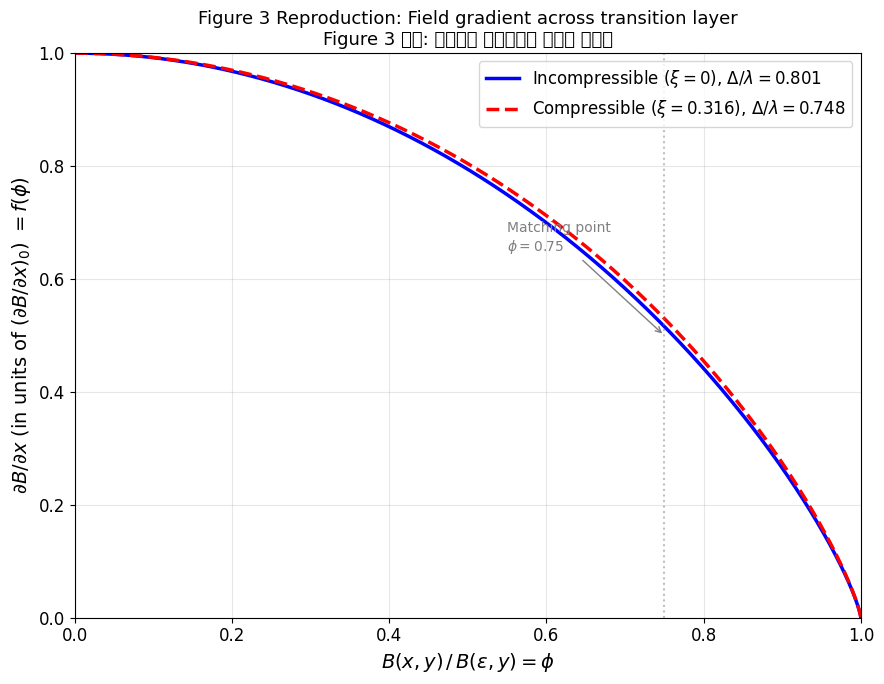


Parker의 결과와 비교 / Comparison with Parker's results:
  비압축성 Δ/λ: 계산 = 0.801, Parker = 0.820
  압축성 Δ/λ:   계산 = 0.748, Parker = 0.772


In [7]:
# ── Reproduce Figure 3: f(φ) = (∂B/∂x)/(∂B/∂x)_0 vs B(x,y)/B(ε,y) ──
# Parker plots ∂B/∂x at x=0 (units of ∂B/∂x at x=0) vs B(x,y)/B(ε,y)

fig, ax = plt.subplots(figsize=(9, 7))

# Incompressible (ξ = 0)
phi_left, f_left = solve_from_zero(DL_incomp, 0.0, phi_max=0.75)
phi_right, f_right = solve_from_one(DL_incomp, 0.0, phi_min=0.75)
phi_incomp = np.concatenate([phi_left, phi_right[::-1]])
f_incomp = np.concatenate([f_left, f_right[::-1]])

ax.plot(phi_incomp, f_incomp, 'b-', lw=2.5,
        label=f'Incompressible ($\\xi = 0$), $\\Delta/\\lambda = {DL_incomp:.3f}$')

# Compressible (ξ = 0.316)
phi_left_c, f_left_c = solve_from_zero(DL_comp, 0.316, phi_max=0.75)
phi_right_c, f_right_c = solve_from_one(DL_comp, 0.316, phi_min=0.75)
phi_comp = np.concatenate([phi_left_c, phi_right_c[::-1]])
f_comp = np.concatenate([f_left_c, f_right_c[::-1]])

ax.plot(phi_comp, f_comp, 'r--', lw=2.5,
        label=f'Compressible ($\\xi = 0.316$), $\\Delta/\\lambda = {DL_comp:.3f}$')

ax.set_xlabel('$B(x, y) \\,/\\, B(\\epsilon, y) = \\phi$', fontsize=14)
ax.set_ylabel('$\\partial B/\\partial x$ (in units of $(\\partial B/\\partial x)_0$) $= f(\\phi)$',
              fontsize=14)
ax.set_title('Figure 3 Reproduction: Field gradient across transition layer\n'
             'Figure 3 재현: 전이층을 가로지르는 자기장 기울기', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=12, loc='upper right')

# Annotate matching point
ax.axvline(0.75, color='gray', ls=':', alpha=0.5)
ax.annotate('Matching point\n$\\phi = 0.75$', xy=(0.75, 0.5), xytext=(0.55, 0.65),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('fig3_parker_figure3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nParker의 결과와 비교 / Comparison with Parker's results:")
print(f"  비압축성 Δ/λ: 계산 = {DL_incomp:.3f}, Parker = 0.820")
print(f"  압축성 Δ/λ:   계산 = {DL_comp:.3f}, Parker = 0.772")

## Part 4: Timescale Comparison / 시간 척도 비교

세 가지 재결합/확산 시간 척도를 비교합니다:
We compare three reconnection/diffusion timescales:

1. **Pure ohmic diffusion / 순수 옴 확산**: $\tau_{\text{diff}} = L^2/\eta$
2. **Sweet-Parker / 스윗-파커**: $\tau_{SP} = L/v_m = \sqrt{R_m} \cdot \tau_A$
3. **Petschek / 페체크**: $\tau_P = \frac{8\ln R_m}{\pi} \cdot \tau_A$

$\tau_A = L/v_A$는 Alfvén 통과 시간입니다. 관측된 플레어 시간 척도(~10² s)와 비교합니다.
$\tau_A = L/v_A$ is the Alfvén transit time. We compare with observed flare timescales (~10² s).

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/806472329.py:37: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/806472329.py:37: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/806472329.py:37: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/806472329.py:37: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_14012/806472329.py:37: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_

/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52377 (\N{HANGUL SYLLABLE CEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45712 (\N{HANGUL SYLLABLE NEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/eunsupark/Sof

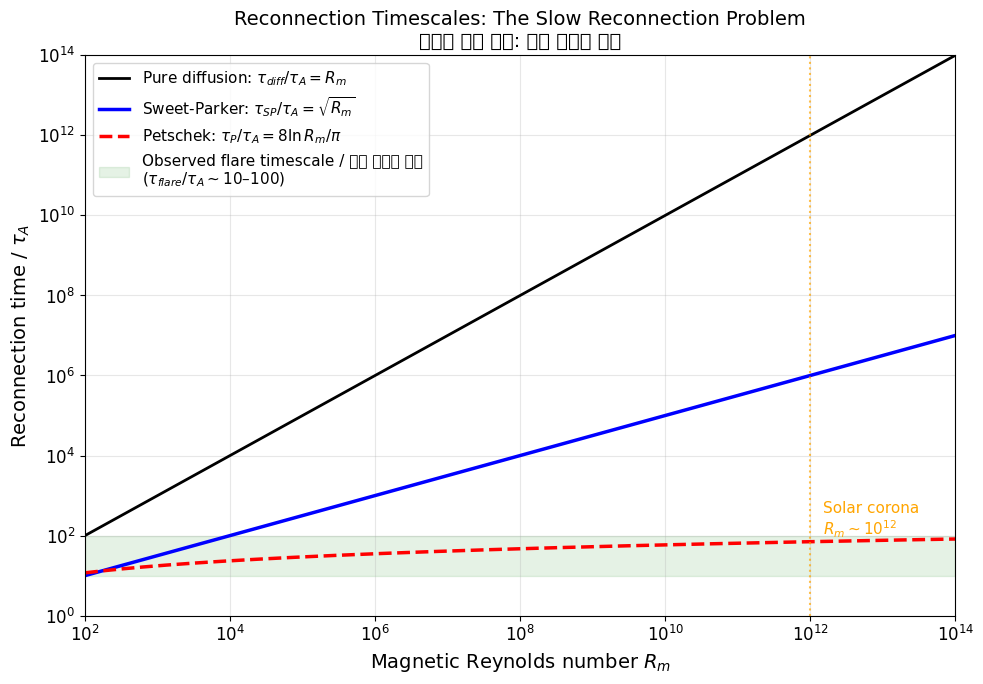

=== Solar Corona Timescales / 태양 코로나 시간 척도 ===
  τ_A = 1.4 s
  τ_SP = √R_m × τ_A = 1.45e+06 s = 16.8 days
  τ_Petschek = (8 ln R_m / π) × τ_A = 102 s = 2 min
  τ_diff = R_m × τ_A = 1.45e+12 s = 45936 yr

  관측된 플레어 시간: ~100–1000 s (수분~수십분)
  Observed flare time: ~100–1000 s (minutes to tens of minutes)

  → Sweet-Parker는 1449배 느림!
  → Sweet-Parker is 1449× too slow!


In [8]:
R_m_range = np.logspace(2, 14, 500)

# Timescales in units of τ_A = L / v_A
tau_diff_norm = R_m_range             # τ_diff / τ_A = R_m
tau_SP_norm = np.sqrt(R_m_range)      # τ_SP / τ_A = √R_m
tau_Petschek_norm = 8 * np.log(R_m_range) / np.pi  # τ_P / τ_A

fig, ax = plt.subplots(figsize=(10, 7))

ax.loglog(R_m_range, tau_diff_norm, 'k-', lw=2,
          label='Pure diffusion: $\\tau_{diff}/\\tau_A = R_m$')
ax.loglog(R_m_range, tau_SP_norm, 'b-', lw=2.5,
          label='Sweet-Parker: $\\tau_{SP}/\\tau_A = \\sqrt{R_m}$')
ax.loglog(R_m_range, tau_Petschek_norm, 'r--', lw=2.5,
          label='Petschek: $\\tau_P/\\tau_A = 8\\ln R_m / \\pi$')

# Mark solar corona
R_m_corona = 1e12
tau_A_corona = corona['tau_A [s]']  # seconds

ax.axvline(R_m_corona, color='orange', ls=':', alpha=0.7, lw=1.5)
ax.text(R_m_corona * 1.5, 1e2, 'Solar corona\n$R_m \\sim 10^{12}$',
        fontsize=11, color='orange')

# Observed flare timescale band (in units of τ_A)
# τ_flare ~ 100-1000 s, τ_A ~ 10 s → τ_flare/τ_A ~ 10-100
ax.axhspan(10, 100, alpha=0.1, color='green',
           label='Observed flare timescale / 관측 플레어 시간\n($\\tau_{flare}/\\tau_A \\sim 10$–$100$)')

ax.set_xlabel('Magnetic Reynolds number $R_m$', fontsize=14)
ax.set_ylabel('Reconnection time / $\\tau_A$', fontsize=14)
ax.set_title('Reconnection Timescales: The Slow Reconnection Problem\n'
             '재결합 시간 척도: 느린 재결합 문제', fontsize=14)
ax.set_xlim(1e2, 1e14)
ax.set_ylim(1, 1e14)
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig('fig4_timescale_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Numerical values for the solar corona
print("=== Solar Corona Timescales / 태양 코로나 시간 척도 ===")
print(f"  τ_A = {tau_A_corona:.1f} s")
print(f"  τ_SP = √R_m × τ_A = {np.sqrt(R_m_corona) * tau_A_corona:.2e} s"
      f" = {np.sqrt(R_m_corona) * tau_A_corona / (3600*24):.1f} days")
print(f"  τ_Petschek = (8 ln R_m / π) × τ_A = "
      f"{8*np.log(R_m_corona)/np.pi * tau_A_corona:.0f} s"
      f" = {8*np.log(R_m_corona)/np.pi * tau_A_corona/60:.0f} min")
print(f"  τ_diff = R_m × τ_A = {R_m_corona * tau_A_corona:.2e} s"
      f" = {R_m_corona * tau_A_corona / (3600*24*365):.0f} yr")
print(f"\n  관측된 플레어 시간: ~100–1000 s (수분~수십분)")
print(f"  Observed flare time: ~100–1000 s (minutes to tens of minutes)")
print(f"\n  → Sweet-Parker는 {np.sqrt(R_m_corona) * tau_A_corona / 1000:.0f}배 느림!")
print(f"  → Sweet-Parker is {np.sqrt(R_m_corona) * tau_A_corona / 1000:.0f}× too slow!")

## Summary / 요약

| Concept / 개념 | This Paper (1957) / 이 논문 | Modern Equivalent / 현대 동등물 |
|---|---|---|
| Merging velocity / 병합 속도 | $v_m = 0.263\, c(C/\sigma L)^{1/2}$ (CGS) | $v_{in} = v_A / \sqrt{R_m}$ (SI) |
| Layer thickness / 층 두께 | $l/L = c/(C_0 L \sigma)^{1/2}$ | $\delta/L = 1/\sqrt{R_m}$ |
| Reconnection time / 재결합 시간 | "about two weeks" for sunspots | $\tau_{SP} = \sqrt{R_m}\, \tau_A$ |
| Compressibility / 압축성 | $v_m$ decreases by ~4% | Negligible for coronal conditions |
| Fast reconnection / 빠른 재결합 | Not addressed | Petschek: $M_A \sim 1/\ln R_m$; Plasmoid: $M_A \sim 0.01$ |
| Field structure / 자기장 구조 | ODE Eq. 26, matched at $\phi = 3/4$ | Harris current sheet: $B_y = B_0 \tanh(x/\delta)$ |

### 핵심 결론 / Key Conclusions

1. **Sweet-Parker 모델은 자기 재결합의 "표준 모형"** — 모든 후속 연구의 기준점
   The Sweet-Parker model is the "standard model" of reconnection — the benchmark for all subsequent work

2. **"느린 재결합 문제"의 발견이 가장 중요한 기여** — 이 문제가 없었다면 빠른 재결합 연구의 동기도 없었을 것
   Discovering the "slow reconnection problem" is the most important contribution

3. **압축성 효과는 미미** ($\sim 4\%$) — 비압축성 근사가 충분히 좋은 근사
   Compressibility effects are negligible (~4%) — incompressible approximation works well

4. **현대적 해결**: Sweet-Parker 전류 시트는 $R_m > 10^4$에서 plasmoid instability로 불안정하여, 자발적으로 빠른 재결합으로 천이 (Loureiro et al. 2007)
   Modern resolution: Sweet-Parker sheets are unstable to plasmoid instability at $R_m > 10^4$, spontaneously transitioning to fast reconnection